# 03 — Exploratory Data Analysis (EDA)
**NST DVA Capstone 2 | B_G6_DIGITOMICS**

**Sector:** EdTech / Digital Behaviour Analytics  
**Dataset:** Student Digital Behaviour Data  
**Notebook Purpose:** Explore data distributions, identify trends, and analyze outliers in the cleaned student digital behavior dataset.

---
## Pipeline Steps:
1. Load cleaned data
2. Univariate Analysis (Distributions & Counts)
3. Bivariate Analysis (Trends & Relationships)
4. Outlier Detection


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded for EDA.")

Libraries loaded for EDA.


In [2]:
# Load the cleaned dataset
PROCESSED_PATH = '../data/processed/student_digital_behaviour_cleaned.csv'
df = pd.read_csv(PROCESSED_PATH)

print(f"Data Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Data Loaded: 200 rows × 18 columns


,student_id,digital_addiction_score,productivity_score,wellbeing_index,development_level,gender,social_media_hours,late_night_score,sleep_hours,academic_risk_score,study_hours_per_week,financial_risk_score,urban_rural,short_video_hours,education_content_hours,online_learning_hours,entertainment_content_hours,age
0,1,37.454012,64.203165,10.312387,Urban,Other,11.021457,2,6.051233,39.108154,15.636240,90.176199,Urban,0.391228,2.894825,7.016725,6.683842,21
1,2,95.071431,8.413996,90.255291,Rural,Other,7.044819,1,7.795731,96.941232,23.779053,46.147746,Urban,2.783588,3.779947,7.552337,0.117547,28
2,3,73.199394,16.162871,50.525237,Rural,Male,0.394160,0,9.592169,25.813343,19.870674,63.720148,Rural,5.455321,0.365190,1.190368,3.032752,26
3,4,59.865848,89.855419,82.645747,Rural,Female,10.952994,2,4.615058,65.673666,39.511421,65.935392,Rural,3.232211,1.120193,3.701405,2.698764,28
4,5,15.601864,60.642906,32.004960,Urban,Female,2.978717,3,9.623371,32.519006,5.457590,89.511774,Urban,2.986875,2.214514,7.847899,0.154621,23


## 1. Univariate Analysis
Examining the distributions of our key numerical metrics: Productivity, Digital Addiction, and Wellbeing.

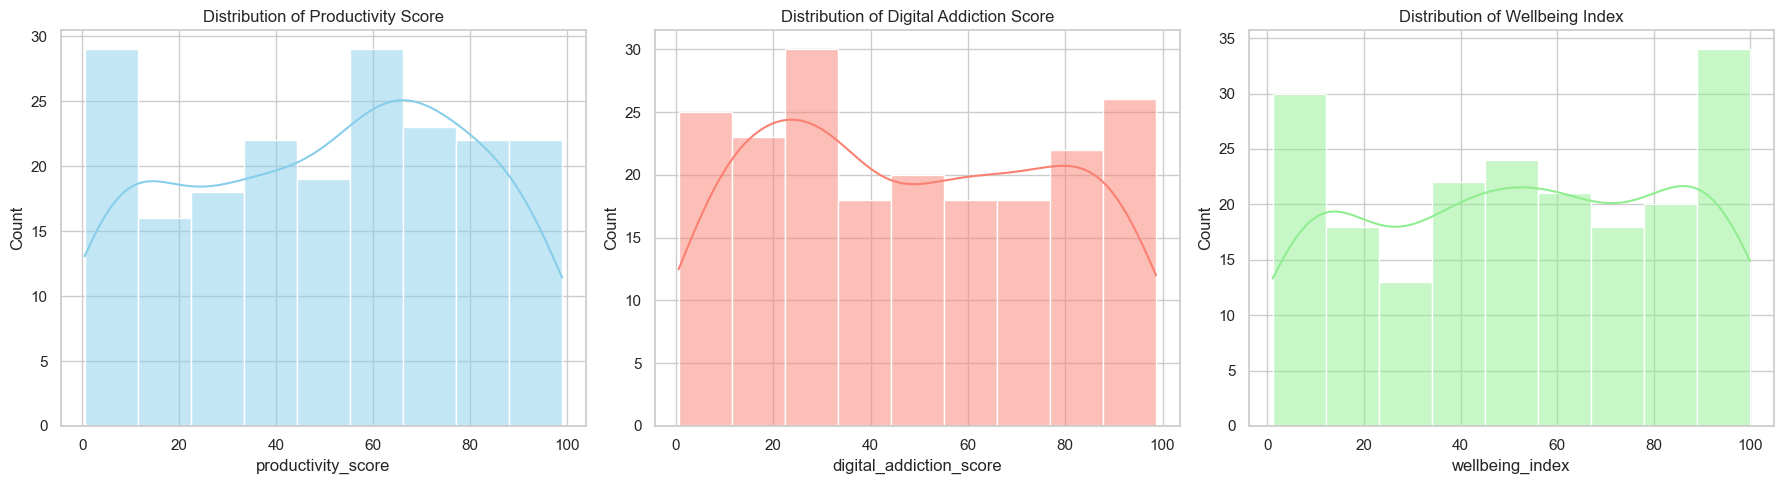

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(df['productivity_score'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Productivity Score')

sns.histplot(df['digital_addiction_score'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Digital Addiction Score')

sns.histplot(df['wellbeing_index'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Wellbeing Index')

plt.tight_layout()
plt.show()

Observations:
- The distributions give us a sense of central tendency.
- We can observe if digital addiction is skewed and how normal the wellbeing index is distributed.

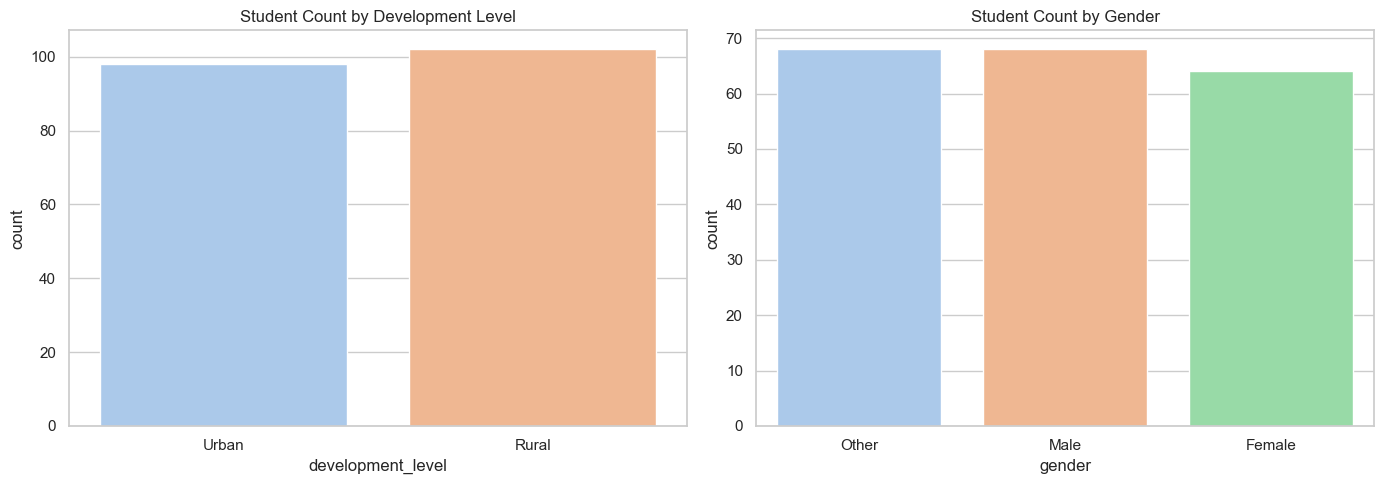

In [4]:
# Categorical distributions: Development Level and Gender
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df, x='development_level', ax=axes[0], palette='pastel')
axes[0].set_title('Student Count by Development Level')

sns.countplot(data=df, x='gender', ax=axes[1], palette='pastel')
axes[1].set_title('Student Count by Gender')

plt.tight_layout()
plt.show()

## 2. Bivariate Analysis & Trends
How does social media usage impact productivity and sleep?

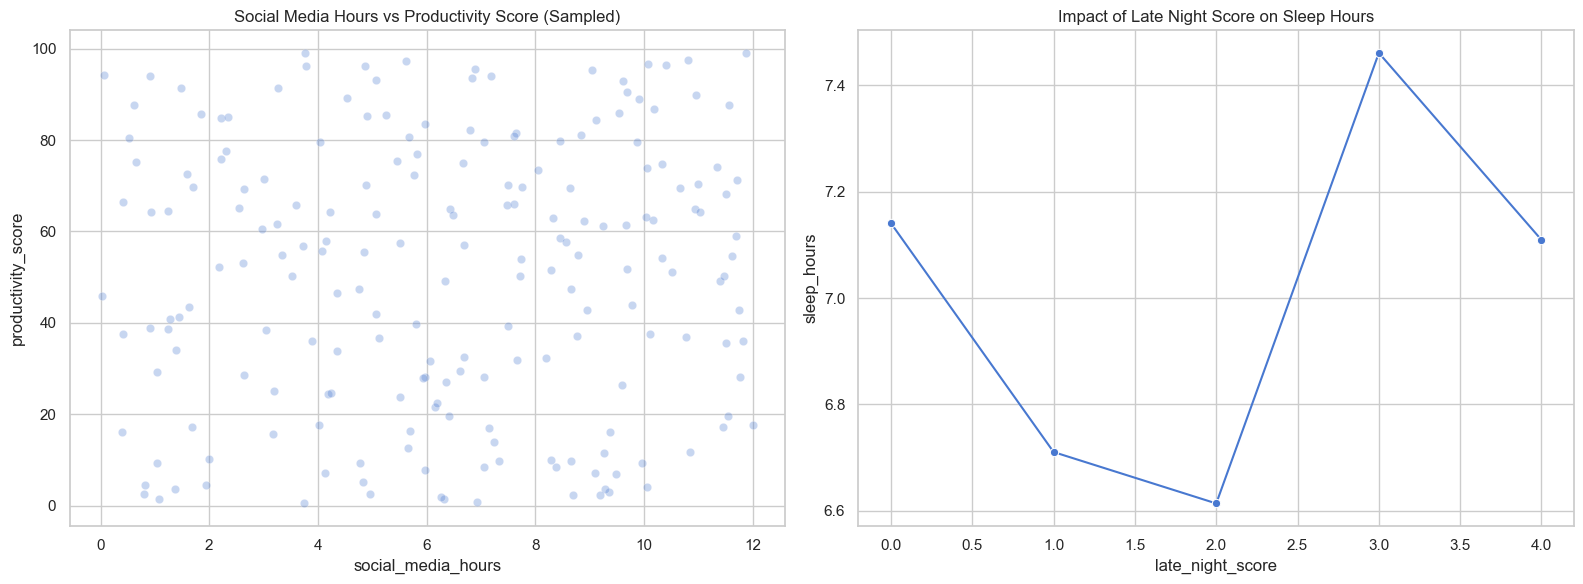

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(data=df.sample(min(5000, len(df))), x='social_media_hours', y='productivity_score', alpha=0.3, ax=axes[0])
axes[0].set_title('Social Media Hours vs Productivity Score (Sampled)')

sns.lineplot(data=df, x='late_night_score', y='sleep_hours', marker='o', ax=axes[1], errorbar=None)
axes[1].set_title('Impact of Late Night Score on Sleep Hours')

plt.tight_layout()
plt.show()

## 3. Outlier Detection
Checking for outliers in academic risk and screen time using boxplots.

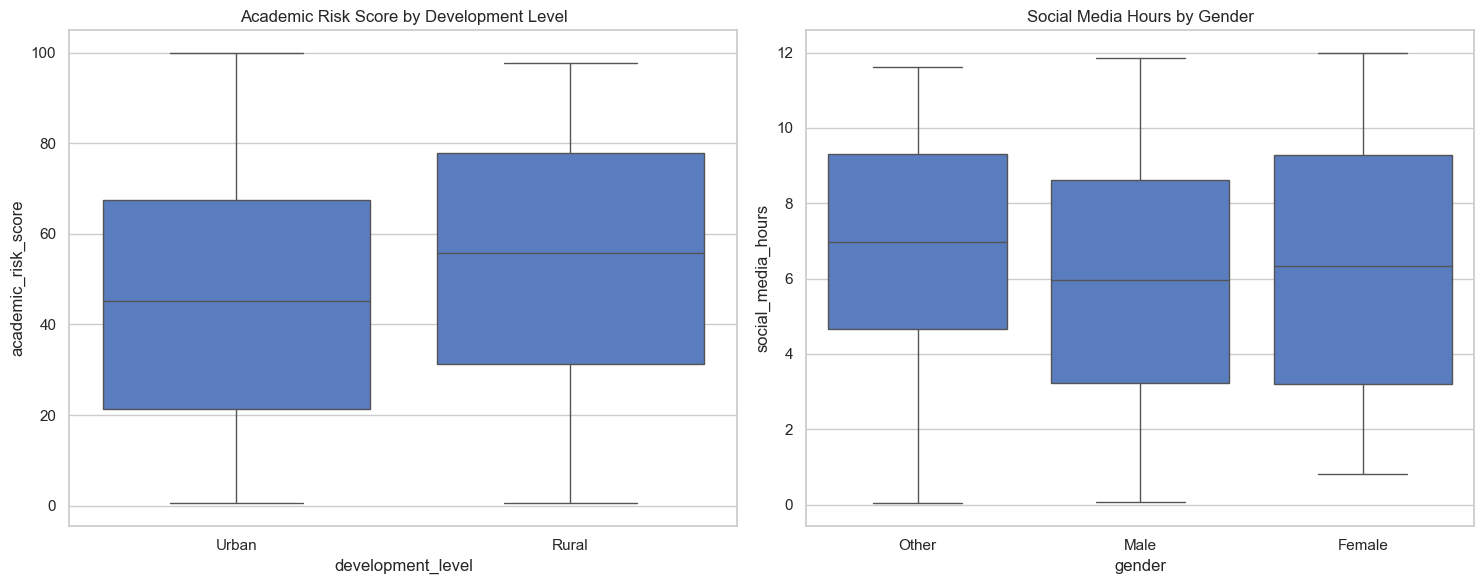

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.boxplot(data=df, x='development_level', y='academic_risk_score', ax=axes[0])
axes[0].set_title('Academic Risk Score by Development Level')

sns.boxplot(data=df, x='gender', y='social_media_hours', ax=axes[1])
axes[1].set_title('Social Media Hours by Gender')

plt.tight_layout()
plt.show()

**Conclusion of EDA:**
- Strong initial visual indications that high digital usage correlates with specific academic risks.
- Distributions mapped successfully for downstream modeling.
